Φυλλάδιο 1 
Μυλωνάκης Αλέξανδρος
ΑΜ: 3045


In [1]:
from morris_counter import morris_counter
from morris_counter_v2 import morris_counter_v2
from morris_counter_v3 import morris_counter_v3
from morris_porbabilities import morris_probabilities
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

Άσκηση 1

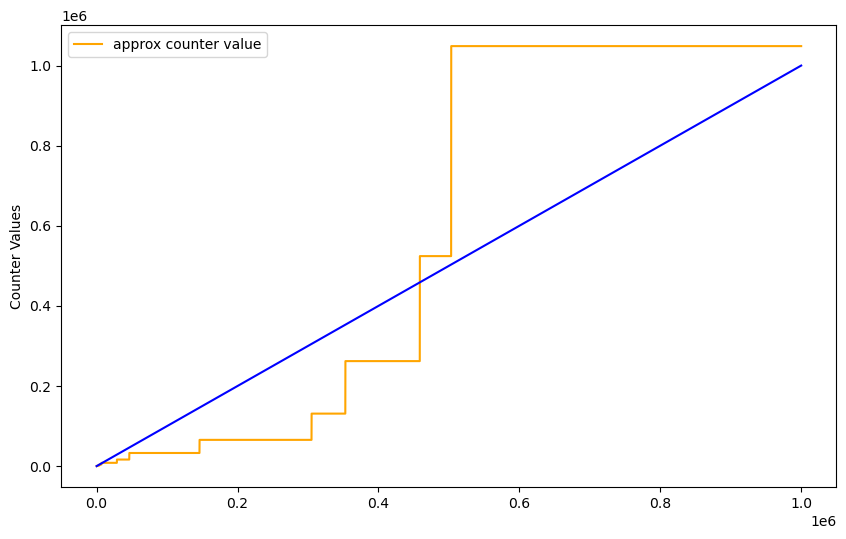

In [6]:
morris = morris_counter()

morris.run_morris_counter(1000000)

morris.morris_graph()


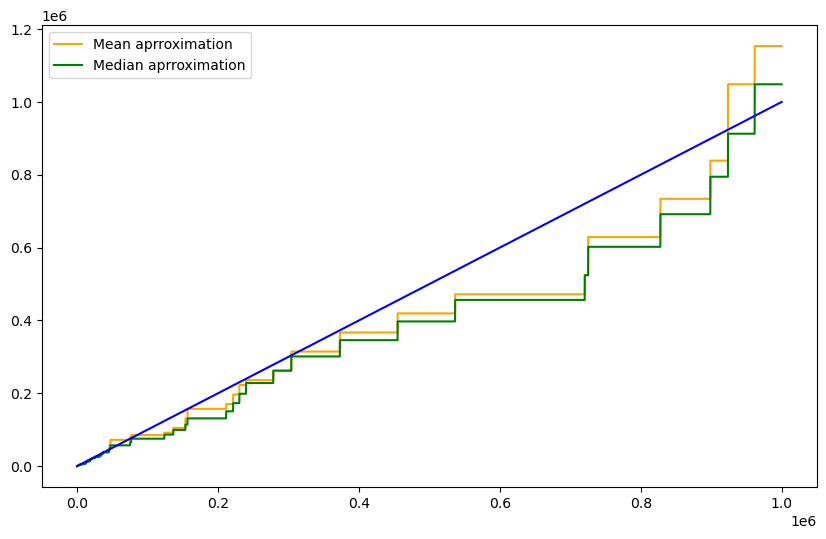

In [7]:
morris2 = morris_counter_v2(5)

morris2.run_morris_counter(1000000)

morris2.morris_graph()


In [8]:
median_array = []
mean_array = []
for i in range(100):
    morris_c =  morris_counter_v2(5)
    morris_c.run_morris_counter(1000000)
    mean,median = morris_c.get_results()
    median_array.append(median)
    mean_array.append(mean)

In [9]:
median_array_10 = []
mean_array_10 = []
for i in range(100):
    morris_c =  morris_counter_v2(10)
    morris_c.run_morris_counter(1000000)
    mean,median = morris_c.get_results()
    median_array_10.append(median)
    mean_array_10.append(mean)

In [10]:
median_array_20 = []
mean_array_20 = []
for i in range(100):
    morris_c =  morris_counter_v2(20)
    morris_c.run_morris_counter(1000000)
    mean,median = morris_c.get_results()
    median_array_20.append(median)
    mean_array_20.append(mean)

In [ ]:
def analyze_mean_median(mean_array, median_array):
    # Υπολογισμός τυπικής απόκλισης
    std_mean = np.std(mean_array)
    std_median = np.std(median_array)

    print(f"Τυπική απόκλιση μέσου όρου: {std_mean:.4f}")
    print(f"Τυπική απόκλιση διάμεσου: {std_median:.4f}")


    # Boxplot
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=[mean_array, median_array])
    plt.xticks([0, 1], ['Μέσος Όρος', 'Διάμεσος'])
    plt.title('Boxplot Μέσου Όρου vs Διάμεσου')
    plt.grid(True)
    plt.show()

    # Ιστόγραμμα
    plt.figure(figsize=(10, 5))
    sns.histplot(mean_array, color='blue', label='Μέσος Όρος', bins=10)
    sns.histplot(median_array, color='green', label='Διάμεσος', bins=10)
    plt.title('Κατανομή Τιμών')
    plt.legend()
    plt.grid(True)
    plt.show()

Τυπική απόκλιση μέσου όρου: 356513.8161
Τυπική απόκλιση διάμεσου: 277320.1473


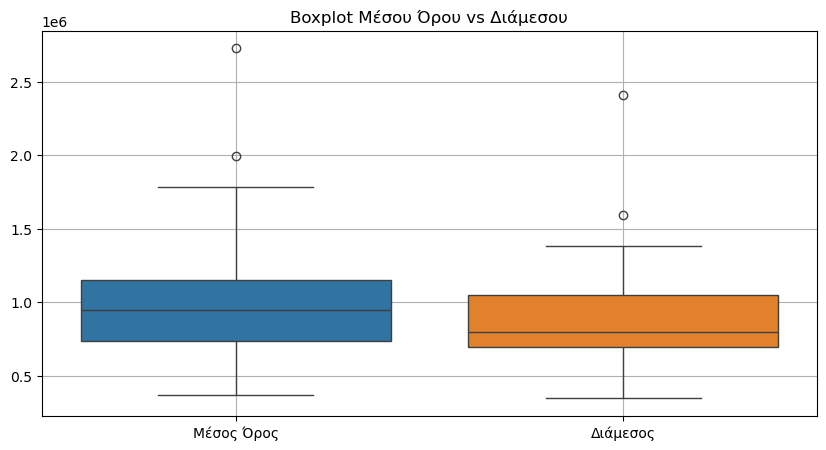

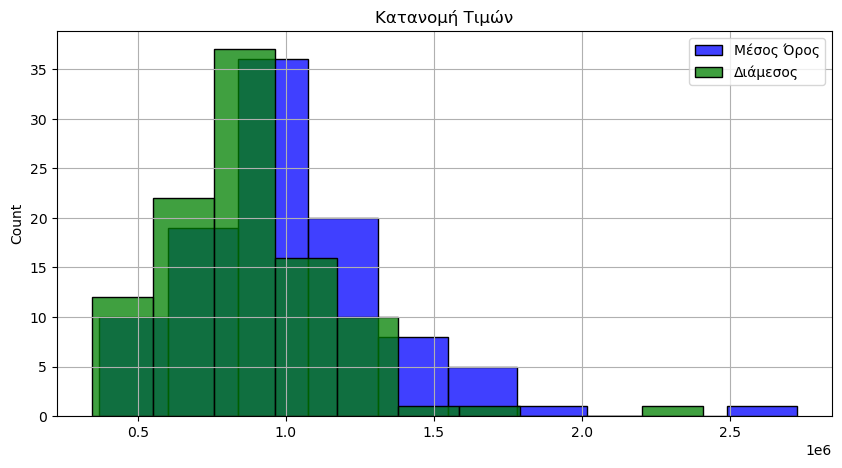

In [52]:
analyze_mean_median(mean_array, median_array)

Τυπική απόκλιση μέσου όρου: 208794.4871
Τυπική απόκλιση διάμεσου: 157176.0267


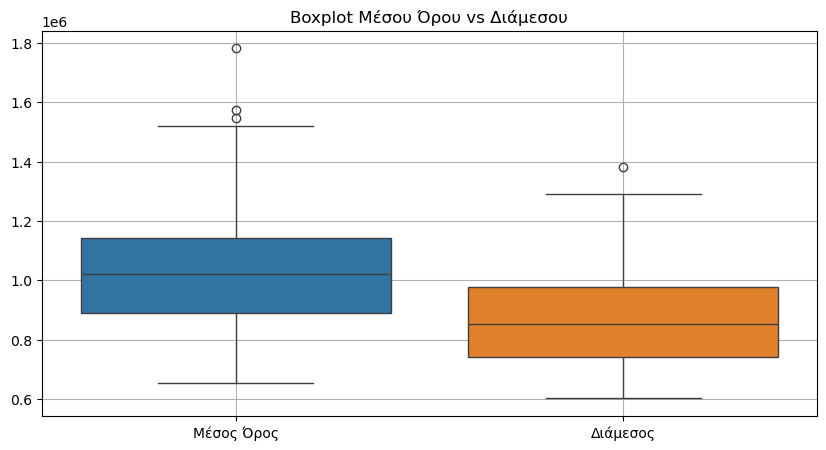

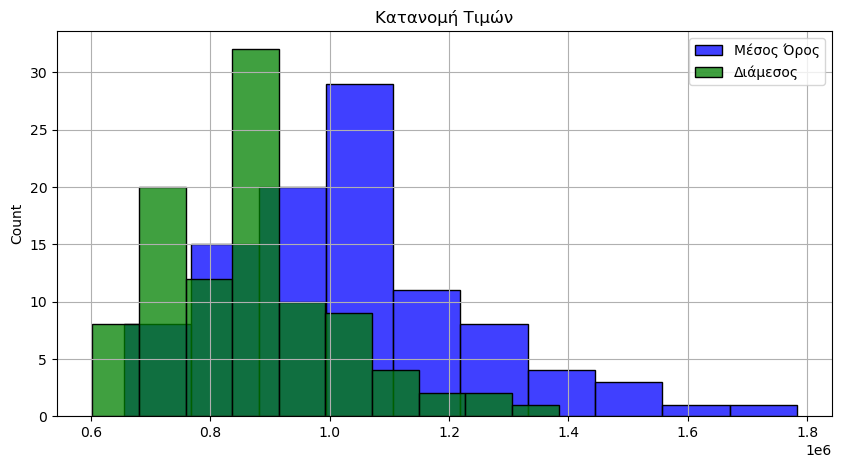

In [53]:
analyze_mean_median(mean_array_10, median_array_10)

Τυπική απόκλιση μέσου όρου: 178592.5623
Τυπική απόκλιση διάμεσου: 123988.6516


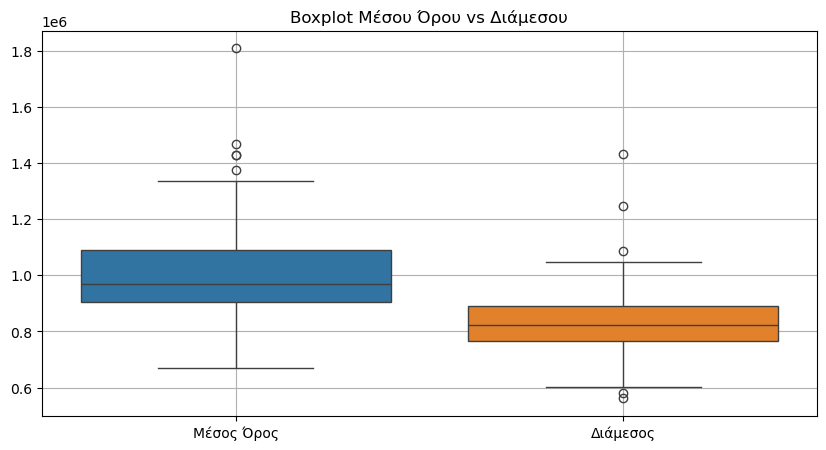

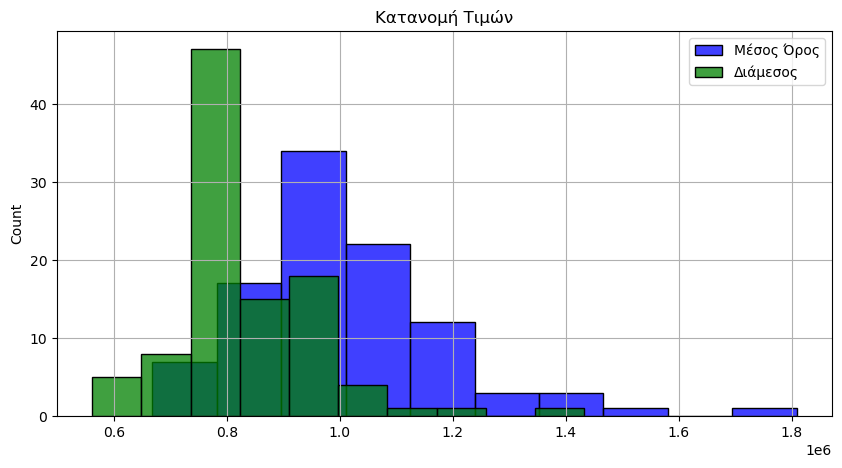

In [54]:
analyze_mean_median(mean_array_20, median_array_20)

Ο μετρητής Morris έχει εκτίμιση n= 2^C -1 και χρησιμοποιεί λογαριθμικό χώρο

Για n=1000000 η τιμή του C είναι περίπου log(n+1)≈20
Άρα για καθε C χρειάζεται 5 bits (για να αποθηκεύσει αριθμούς μέχρι 31)
Αρα για 5 μεταβλητές C χρησιμοποιώ 25 bits αντι για 1 που χρειάζεται μόνο 5
Το κέρδος σε ακρίβεια είναι μικρό σε σχέση με την αύξηση του χώρου. Αν ο στόχος είναι η εξοικονόμηση μνήμης, τοτε η χρήση πολλών C δεν είναι αποδοτική για μεγάλα n.

Η χρήση πολλών μεταβλητών θα είχε νόημα για μικρά n διότι η ακρίβεια του Morris μετρητή είναι χαμηλή (μεγάλη σχετική απόκλιση) και η χρήση πολλών C βελτιώνει την εκτίμηση σημαντικά.

In [7]:
def compute_P(n_max, k_max):
    P = []
    for n in range(n_max + 1):
        row = []
        for k in range(k_max + 2):
            row.append(0.0)
        P.append(row)

    P[1][1] = 1.0 

    for n in range(2, n_max + 1):
        for k in range(1, k_max + 1):
            P[n][k] = P[n-1][k-1] * (1 / (2 ** (k - 1))) + P[n-1][k] * (1 - 1 / (2 ** k))

    return P

In [ ]:
n_max = 1000000
k_max =20
moris_prob = morris_probabilities(n_max,k_max)
p_8 = moris_prob.get_probability(1000,8)
p_9 = moris_prob.get_probability(1000,9)
p_10 = moris_prob.get_probability(1000,10)
p_11 = moris_prob.get_probability(1000,11)
print(p_8+p_9+p_10 + p_11)


0.9799944756624452


In [6]:
P_table = moris_prob.get_p()

AttributeError: 'morris_probabilities' object has no attribute 'get_p'

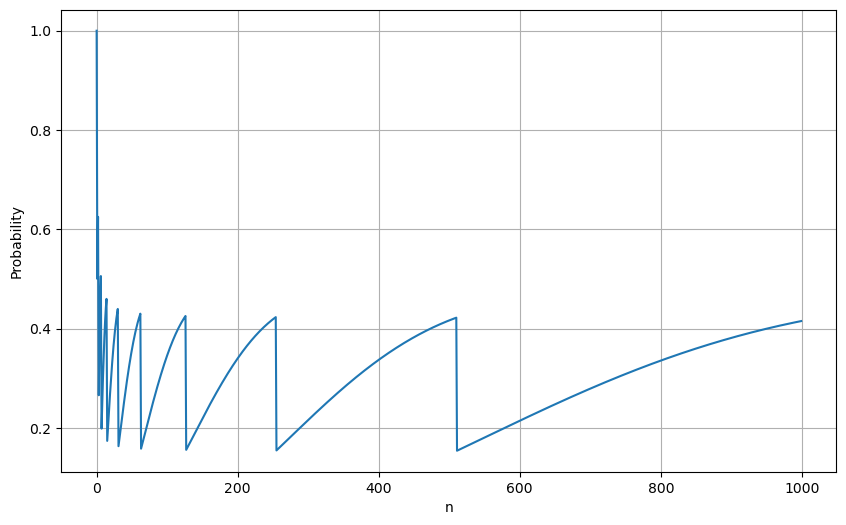

In [ ]:
probability_dict = {}
for i in range(1, 1001):
    k = math.ceil(math.log2(i + 1))
    probability_dict[i] = P_table[i][k-1]

plt.figure(figsize=(10, 6))
plt.plot(list(probability_dict.values()))
plt.xlabel("n")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

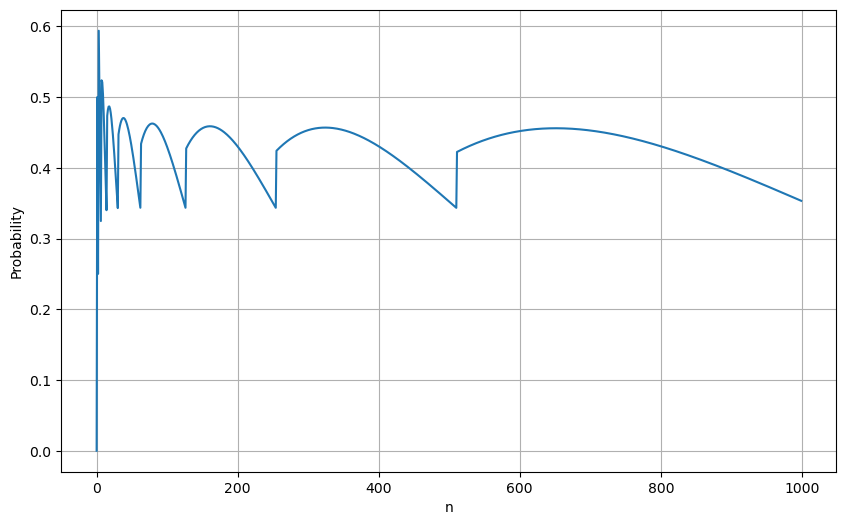

In [ ]:
probability_dict_2 = {}
for i in range(1, 1001):
    k = math.ceil(math.log2(i + 1))
    probability_dict_2[i] = P_table[i][k-1]
plt.figure(figsize=(10, 6))
plt.plot(list(probability_dict_2.values()))
plt.xlabel("n")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

In [13]:

probability_dict_3 = {}
for i in range(1, 1001):
    k = math.ceil(math.log2(i + 1))
    probability_dict_3[i] = P_table[i][k+1]

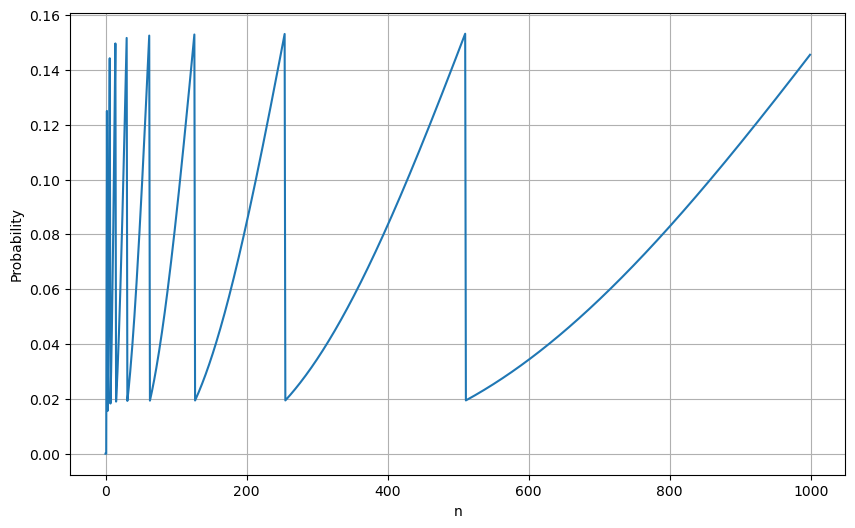

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(list(probability_dict_3.values()))
plt.xlabel("n")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

Αν θέλουμε να μετρήσουμε μέχρι n =1.000.000 τότε πρεπει να βρούμε το ελάχιστο c ώστε
    2^c -1 >= 1.000.000 => 2^c>=1.000.001 => c>=log2(1.000.001)≈19.93
Άρα χρειαζόμαστε τουλάχιστον 20 διαφορετικες τιμές του μετρήτη c δηλαδή:
    ceil(log2(20)) = 5 bits
Με 5 bits μπορούμε να αναπαραστήσουμε τιμές από 0 έως 31.
Ο μετρητής Morris  χρειάζεται μόνο 5 bits για να μετρήσει μέχρι 1.000.000. Άρα τα 8 bits που έχουμε στη διάθεσή μας είναι περισσότερα απ’ όσα απαιτούνται, και μας δίνουν περιθώριο για πολύ μεγαλύτερες εκτιμήσεις.


Με 8 bits μπορούμε να αναπαραστήσουμε τιμές από 0 έως 255.
Αρα για α = 1,056 => α^255 ≈1.080.000 εχω πληρη αξιοποίηση των 8 bits 

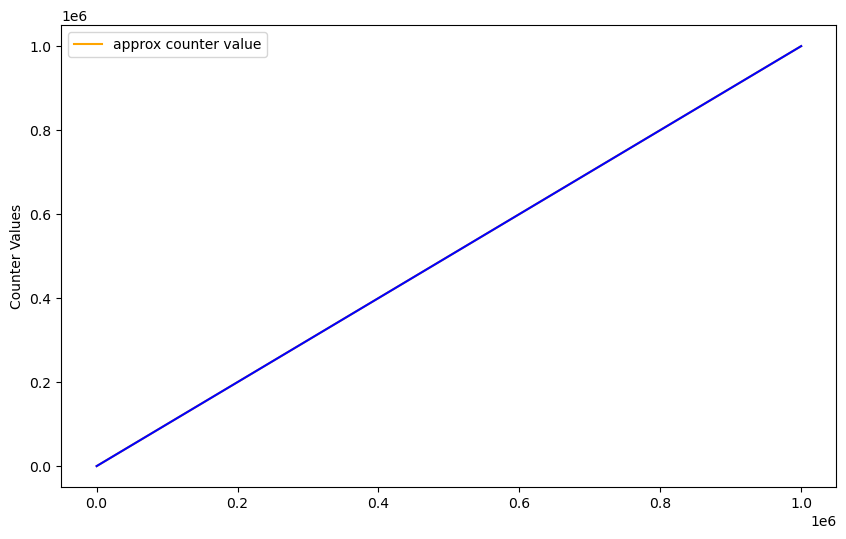

In [2]:
morris3 = morris_counter_v3(1)

morris3.run_morris_counter(1000000)

morris3.morris_graph()


Η αναμενόμενη τιμή του πλήθους 𝑛 μετά από 𝐶 αυξήσεις είναι ο άθροισμα γεωμετρικής προόδου με λόγο 
𝛼 και 𝐶 όρους αρα η εκτίμηση  είναι : n = 1/(a-1)*(a^c-1)


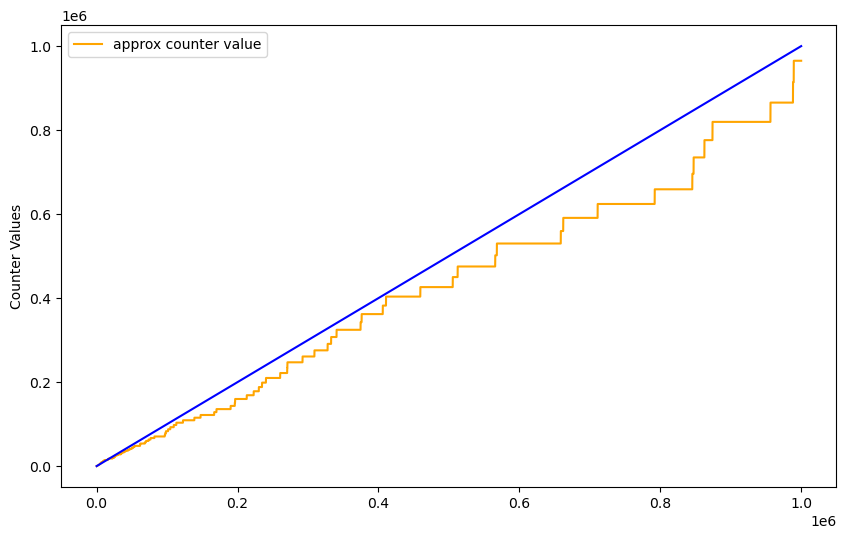

In [13]:
morris3 = morris_counter_v3(1.056)

morris3.run_morris_counter(1000000)

morris3.morris_graph()